# Environment

In [1]:
import os
from pathlib import Path
os.chdir('/Users/burkelawlor/Repos/hci-irae')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium
import sopa

from utils.processing import propogate_subset_labels, get_ranked_genes_by_group
from utils.plotting import feature_plots_from_marker_genes, spatial_plot_cell_types_individual, spatial_plot_cell_types_layered, plot_proportions_bar

In [2]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load data

In [3]:
adata_rmc = ad.read_h5ad("./data/adata/rmc_annotated_4_epithelial.h5ad")

# Cleaning up annotations and exploring

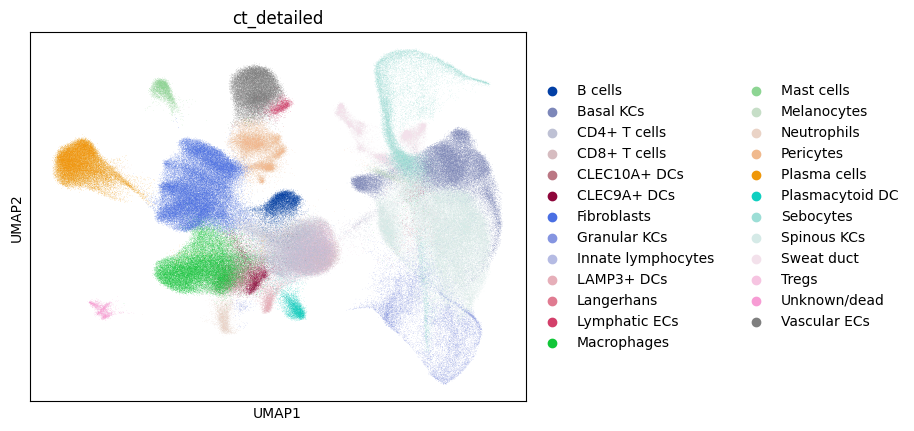

In [4]:
ax = sc.pl.umap(adata_rmc, color=['ct_detailed'], show=False)
ax.figure.savefig("./figures/umaps/detailed_annotation_umap.png", bbox_inches="tight")

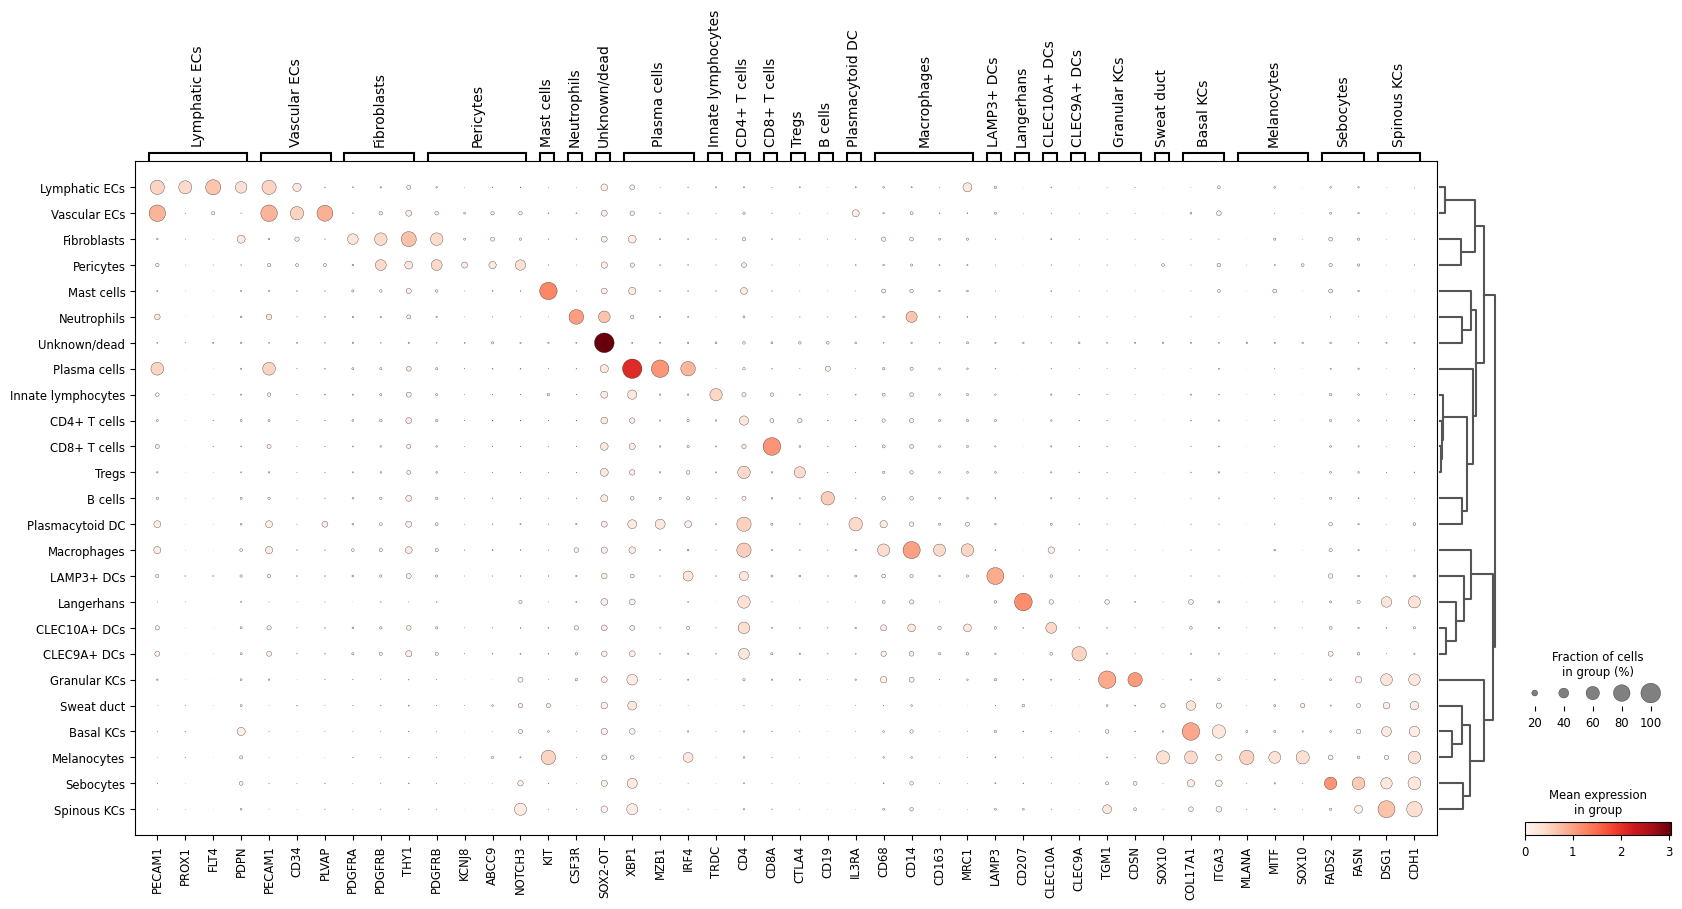

In [5]:
marker_genes_detailed = {
    "Fibroblasts": ["PDGFRA", "PDGFRB",'THY1'],
    'Pericytes': ['PDGFRB','KCNJ8','ABCC9','NOTCH3'],
    "Sweat duct": ["SOX10"],

    # Myeloid
    'Mast cells':['KIT'],
    'Neutrophils':['CSF3R'],
    'Macrophages':['CD68','CD14','CD163','MRC1'],
    'Langerhans':['CD207'],
    'CLEC10A+ DCs':['CLEC10A',],#'CIITA'
    'CLEC9A+ DCs':['CLEC9A',],#'CIITA'
    # 'CXCL9+ DCs':['CXCL9',],#'CIITA'
    'LAMP3+ DCs':['LAMP3',],#'CIITA'
    'Plasmacytoid DC':['IL3RA',],#'CIITA'

    # B cells
    'B cells': ['CD19'],
    'Plasma cells':['XBP1','MZB1','IRF4'],

    # T cells
    'CD8+ T cells':['CD8A'],#'CD3E'
    'CD4+ T cells':['CD4'],#'CD3E'
    'Tregs':['CTLA4'],#'CD3E'
    'Innate lymphocytes':['TRDC'],#'CD3E'
    # 'NK cells':['KLRB1'],#'CD3E'

    # Endothelial
    'Vascular ECs': ['PECAM1','CD34','PLVAP'],
    'Lymphatic ECs': ['PECAM1','PROX1','FLT4','PDPN'],

    # Epithelial
    'Sebocytes':['FADS2','FASN'],
    'Basal KCs':['COL17A1','ITGA3'],#GRN
    'Spinous KCs':['DSG1','CDH1'],#GRN
    'Granular KCs':['TGM1','CDSN'],#GRN
    'Melanocytes': ["MLANA", "MITF", "SOX10"],
    
    
    'Unknown/dead': ['SOX2-OT'],
}

order = marker_genes_detailed.keys() 
ax = sc.pl.dotplot(adata_rmc, marker_genes_detailed, "ct_detailed", dendrogram=True, show=False, categories_order=order)
ax['mainplot_ax'].figure.savefig("./figures/dotplots/detailed_annotation_dotplot.png", bbox_inches="tight")


# Save to Xenium

In [6]:
# from utils.data_loading import xenium_paths

# for sample, path in xenium_paths.items():
#     adata = adata_rmc[adata_rmc.obs['sample_name'] == sample]
#     adata.obs.drop(columns=['sample_name','sample_set','batch','leiden_25','leiden_20','leiden_03'],inplace=True)
#     sopa.io.explorer.write_cell_categories(path, adata)

In [7]:
# adata_EPD4 = adata_rmc[adata_rmc.obs['sample_name'] == 'EPD4']
# adata_EPD4.obs.drop(columns=['sample_name','sample_set','batch','leiden_25','leiden_20','leiden_10','leiden_03'],inplace=True)

# explorer_path = Path("./data/Xenium/26697R/output-XETG00516__0076678__Region_6__20251017__213834")
# # explorer_path = Path("./data/Xenium/processed/EPD4")
# sopa.io.explorer.write_cell_categories(explorer_path, adata_EPD4)